In [ ]:
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.nn import functional as F

from torch.utils.data import TensorDataset, DataLoader
import random

sns.set(style="darkgrid", font_scale=1.4)

In [ ]:
# Reduce stochasticity

SEED = 42

# PyTorch
torch.manual_seed(SEED)

# CUDA (GPU)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # For multi-GPU setups

# NumPy
np.random.seed(SEED)

# Python's built-in random
random.seed(SEED)

In [ ]:
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)

In [ ]:
X, y = make_moons(n_samples=10000, random_state=42, noise=0.1)

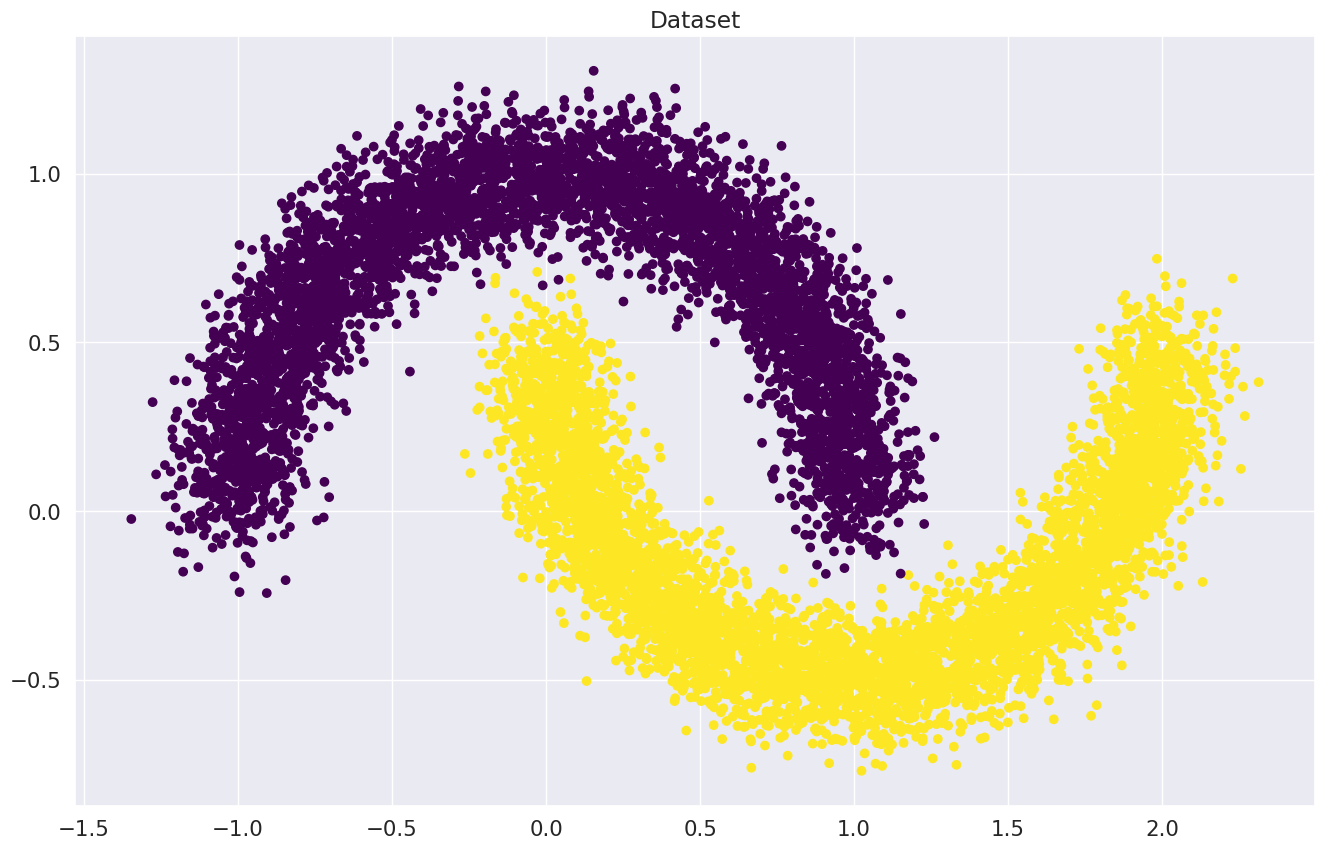

In [ ]:
plt.figure(figsize=(16, 10))
plt.title("Dataset")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis")
plt.show()

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42)

In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.int64)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.int64)

In [ ]:
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_dataloader = DataLoader(train_dataset, batch_size=128)
val_dataloader = DataLoader(val_dataset, batch_size=128)

In [ ]:
class LinearRegression(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(in_features, out_features))
        self.bias = bias
        if bias:
            self.bias_term = nn.Parameter(torch.randn(out_features))
        else:
          self.bias_term = None

    def forward(self, x):
        x = torch.matmul(x, self.weights)
        if self.bias:
            x += self.bias_term
        return x

In [ ]:
linear_regression = LinearRegression(2, 1)
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(linear_regression.parameters(), lr=0.05)

In [ ]:
linear_regression = LinearRegression(2, 1)

total_params = sum(p.numel() for p in linear_regression.parameters())
print(f"Количество обучаемых параметров: {total_params}")

Количество обучаемых параметров: 3


### Train loop

Перейдём непосредственно к обучению.

Вот псевдокод, который поможет вам разобраться в том, что происходит во время обучения

```python
for epoch in range(max_epochs):  # <----------- итерируемся по датасету несколько раз
    for x_batch, y_batch in dataset:  # <------ итерируемся по датасету. Так как мы используем SGD а не GD, то берем батчи заданного размера
        optimizer.zero_grad()  # <------------- обнуляем градиенты модели
        outp = model(x_batch)  # <------------- получаем "логиты" из модели
        loss = loss_func(outp, y_batch)  # <--- считаем "лосс" для логистической регрессии
        loss.backward()  # <------------------- считаем градиенты
        optimizer.step()  # <------------------ делаем шаг градиентного спуска
        if convergence:  # <------------------- в случае сходимости выходим из цикла
            break
```

В коде ниже добавлено логирование `accuracy` и `loss`.

In [ ]:
tol = 1e-3
losses = []
max_epochs = 100
prev_weights = torch.zeros_like(linear_regression.weights)
stop_it = False
for epoch in range(max_epochs):
    for it, (X_batch, y_batch) in enumerate(train_dataloader):
        optimizer.zero_grad()
        outp =  linear_regression(X_batch)
        loss = loss_function(outp.squeeze(1), y_batch.float())
        loss.backward()
        losses.append(loss.detach().flatten()[0])
        optimizer.step()
        probabilities =  probabilities = torch.sigmoid(outp)
        preds = (probabilities > 0.5).type(torch.long)
        batch_acc = (preds.flatten() == y_batch).type(torch.float32).sum() / y_batch.size(0)

        if (it + epoch * len(train_dataloader)) % 100 == 0:
            print(f"Iteration: {it + epoch * len(train_dataloader)}\nBatch accuracy: {batch_acc}")
        current_weights = linear_regression.weights.detach().clone()
        if (prev_weights - current_weights).abs().max() < tol:
            print(f"\nIteration: {it + epoch * len(train_dataloader)}.Convergence. Stopping iterations.")
            stop_it = True
            break
        prev_weights = current_weights
    if stop_it:
        break

Iteration: 0
Batch accuracy: 0.8515625

Iteration: 1.Convergence. Stopping iterations.


In [ ]:
convergence_iteration = it + epoch * len(train_dataloader)
print(f"Алгоритм сошёлся за {convergence_iteration} итераций.")


Алгоритм сошёлся за 1 итераций.


### Визуализируем результаты

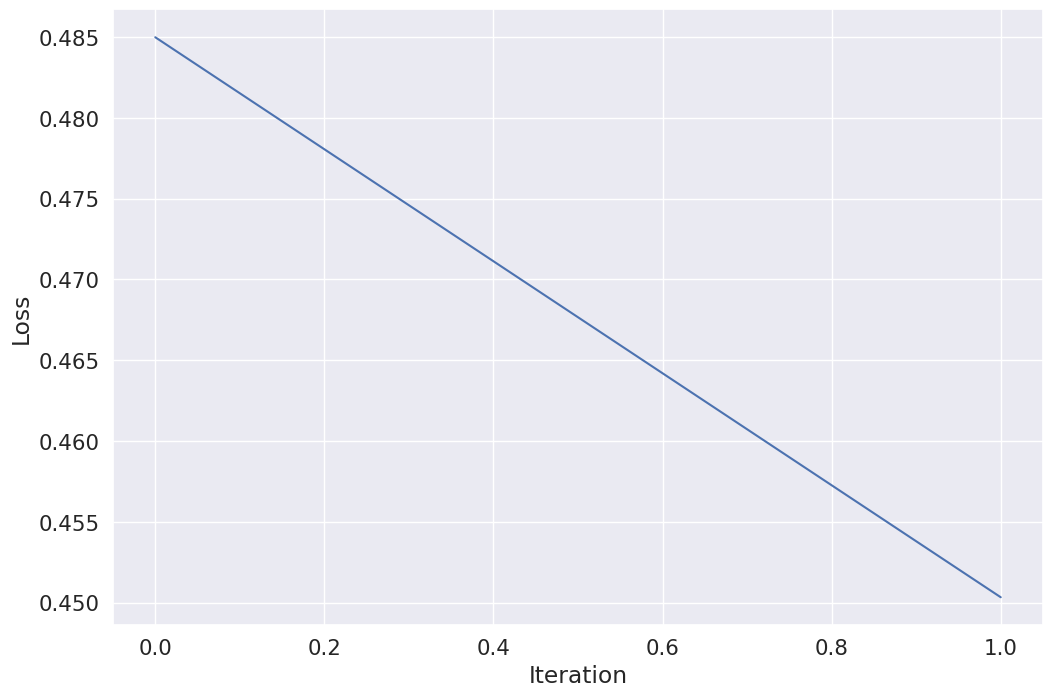

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(range(len(losses)), losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

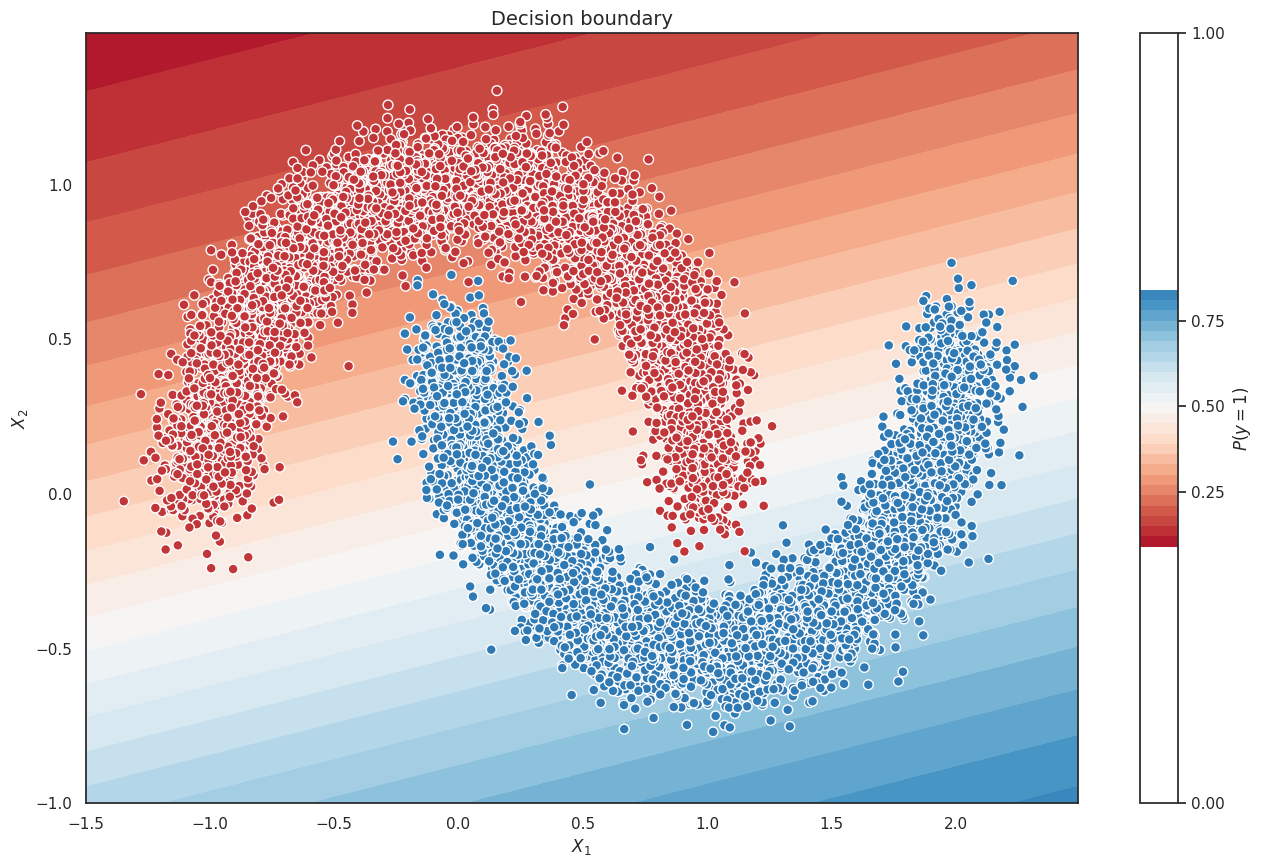

In [ ]:
import numpy as np

sns.set(style="white")

xx, yy = np.mgrid[-1.5:2.5:.01, -1.:1.5:.01]
grid = np.c_[xx.ravel(), yy.ravel()]
batch = torch.from_numpy(grid).type(torch.float32)
with torch.no_grad():
    probs = torch.sigmoid(linear_regression(batch).reshape(xx.shape))
    probs = probs.numpy().reshape(xx.shape)

f, ax = plt.subplots(figsize=(16, 10))
ax.set_title("Decision boundary", fontsize=14)
contour = ax.contourf(xx, yy, probs, 25, cmap="RdBu",
                      vmin=0, vmax=1)
ax_c = f.colorbar(contour)
ax_c.set_label("$P(y = 1)$")
ax_c.set_ticks([0, .25, .5, .75, 1])

ax.scatter(X[100:,0], X[100:, 1], c=y[100:], s=50,
           cmap="RdBu", vmin=-.2, vmax=1.2,
           edgecolor="white", linewidth=1)

ax.set(xlabel="$X_1$", ylabel="$X_2$")
plt.show()

### Задание. Реализуйте predict и посчитайте accuracy на test.



In [ ]:
@torch.no_grad()
def predict(dataloader, model):
    model.eval()
    predictions = np.array([])
    for x_batch, _ in dataloader:
        outp = model(x_batch)
        probabilities = torch.sigmoid(outp)
        preds = (probabilities > 0.5).type(torch.long)
        predictions = np.hstack((predictions, preds.numpy().flatten()))
    return predictions.flatten()

In [ ]:
from sklearn.metrics import accuracy_score


y_pred = predict(val_dataloader, linear_regression)

# Истинные метки
y_true = y_val_t.numpy()


accuracy = accuracy_score(y_true, y_pred)

print(f"Total accuracy on test set: {accuracy:.4f}")


Total accuracy on test set: 0.8532


In [ ]:
import os
from torchvision.datasets import MNIST
from torchvision import transforms as tfs


data_tfs = tfs.Compose([
    tfs.ToTensor(),
    tfs.Normalize((0.5), (0.5))
])

# install for train and test
root = './'
train_dataset = MNIST(root, train=True,  transform=data_tfs, download=True)
val_dataset  = MNIST(root, train=False, transform=data_tfs, download=True)

train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
valid_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.47MB/s]


In [ ]:
activation = nn.ELU()

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    activation,
    nn.Linear(128, 128),
    activation,
    nn.Linear(128, 10)
)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

loaders = {"train": train_dataloader, "valid": valid_dataloader}

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

### Train loop (seriously)

Давайте разберемся с кодом ниже, который подойдет для 90% задач в будущем.


```python
for epoch in range(max_epochs):  # <--------------- итерируемся по датасету несколько раз
    for k, dataloader in loaders.items():  # <----- несколько dataloader для train / valid / test
        for x_batch, y_batch in dataloader:  # <--- итерируемся по датасету. Так как мы используем SGD а не GD, то берем батчи заданного размера
            if k == "train":
                model.train()  # <------------------ переводим модель в режим train
                optimizer.zero_grad()  # <--------- обнуляем градиенты модели
                outp = model(x_batch)
                loss = criterion(outp, y_batch) # <-считаем "лосс" для логистической регрессии
                loss.backward()  # <--------------- считаем градиенты
                optimizer.step()  # <-------------- делаем шаг градиентного спуска
            else:  # <----------------------------- test/eval
                model.eval()  # <------------------ переводим модель в режим eval
                with torch.no_grad():  # <--------- НЕ считаем градиенты
                    outp = model(x_batch)  # <------------- получаем "логиты" из модели
            count_metrics(outp, y_batch)  # <-------------- считаем метрики
```

### Задание. Дополните цикл обучения.

In [ ]:
max_epochs = 10
accuracy = {"train": [], "valid": []}

for epoch in range(max_epochs):
    for k, dataloader in loaders.items():
        epoch_correct = 0
        epoch_all = 0

        for x_batch, y_batch in dataloader:
            if k == "train":
                model.train()
                optimizer.zero_grad()  # Обнуляем градиенты
                outp = model(x_batch)
            else:
                model.eval()  # Устанавливаем модель в режим оценки (не обучаем)
                with torch.no_grad():
                    outp = model(x_batch)

            # Вычисляем предсказания (по индексу максимального логита)
            preds = outp.argmax(-1)

            # Подсчитываем количество правильных предсказаний и общее количество
            correct = (preds == y_batch).sum()
            all = y_batch.size(0)

            epoch_correct += correct.item()  # Добавляем правильные предсказания в эту эпоху
            epoch_all += all

            if k == "train":
                loss = criterion(outp, y_batch)  # Вычисляем лосс
                loss.backward()
                optimizer.step()

        print(f"Epoch: {epoch+1}, Loader: {k}, Accuracy: {epoch_correct/epoch_all:.4f}")
        accuracy[k].append(epoch_correct / epoch_all)  # Сохраняем точность


Epoch: 1, Loader: train, Accuracy: 0.8867
Epoch: 1, Loader: valid, Accuracy: 0.9373
Epoch: 2, Loader: train, Accuracy: 0.9482
Epoch: 2, Loader: valid, Accuracy: 0.9606
Epoch: 3, Loader: train, Accuracy: 0.9638
Epoch: 3, Loader: valid, Accuracy: 0.9642
Epoch: 4, Loader: train, Accuracy: 0.9707
Epoch: 4, Loader: valid, Accuracy: 0.9658
Epoch: 5, Loader: train, Accuracy: 0.9755
Epoch: 5, Loader: valid, Accuracy: 0.9702
Epoch: 6, Loader: train, Accuracy: 0.9797
Epoch: 6, Loader: valid, Accuracy: 0.9728
Epoch: 7, Loader: train, Accuracy: 0.9813
Epoch: 7, Loader: valid, Accuracy: 0.9716
Epoch: 8, Loader: train, Accuracy: 0.9821
Epoch: 8, Loader: valid, Accuracy: 0.9734
Epoch: 9, Loader: train, Accuracy: 0.9850
Epoch: 9, Loader: valid, Accuracy: 0.9767
Epoch: 10, Loader: train, Accuracy: 0.9882
Epoch: 10, Loader: valid, Accuracy: 0.9748


### Задание. Протестируйте разные функции активации.
Попробуйте разные функции активации. Для каждой функции активации посчитайте массив validation accuracy. Лучше реализовать это в виде функции, берущей на вход активацию и получающей массив из accuracies.

Функции активации добавляют ***нелинейность в модель***, что позволяет сети решать сложные задачи, такие как классификация и регрессия. Без функций активации нейронная сеть была бы линейной моделью, так как ***композиция линейных преобразований*** это ***линейное преобразование***.

**ReLU (Rectified Linear Unit)**
   - Формула: $ f(x) = \max(0, x) $
   - Диапазон значений: $ [0, \infty) $

**Leaky ReLU**
   - Формула: $ f(x) = \max(\alpha x, x) $, где $ \alpha $ — маленькое положительное число (обычно $ \alpha = 0.01 $).
   - Диапазон значений: $ (-\infty, \infty) $

**Exponential Linear Unit (ELU)**
   - Формула:
   $f(x) = $
     \begin{cases}
     x & \text{если } x > 0 \\
     \alpha (e^x - 1) & \text{если } x \leq 0
     \end{cases}
   - Диапазон значений:  $ (-\alpha, \infty) $

**Линейная функция активации**
   - Формула: $ f(x) = x $
   - Диапазон значений: $ (-\infty, \infty) $

   Обратите внимание, что данная функция активации **не добавляет** нелинейности.

In [ ]:
elu_accuracy = accuracy["valid"]

In [ ]:
def test_activation_function(activation):
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 128),
        activation,
        nn.Linear(128, 128),
        activation,
        nn.Linear(128, 10)
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    accuracy = {"train": [], "valid": []}

    # Процесс обучения и валидации
    for epoch in range(max_epochs):
        for k, dataloader in loaders.items():
            epoch_correct = 0
            epoch_all = 0
            for x_batch, y_batch in dataloader:
                if k == "train":
                    model.train()
                    optimizer.zero_grad()
                    outp = model(x_batch)
                else:
                    model.eval()
                    with torch.no_grad():
                        outp = model(x_batch)

                # Предсказания
                preds = outp.argmax(-1)
                correct = (preds == y_batch).sum()
                all = y_batch.size(0)

                epoch_correct += correct.item()
                epoch_all += all

                if k == "train":
                    loss = criterion(outp, y_batch)
                    loss.backward()
                    optimizer.step()

            accuracy[k].append(epoch_correct / epoch_all)
            if k == "train":
                print(f"Epoch: {epoch+1}, Loader: {k}, Accuracy: {epoch_correct/epoch_all:.4f}")
    return accuracy["valid"]  # Возвращаем точность на валидационном наборе


In [ ]:
plain_accuracy = test_activation_function(nn.Identity()) #There is no non-linearity
relu_accuracy = test_activation_function(nn.ReLU())
leaky_relu_accuracy = test_activation_function(nn.LeakyReLU(0.01))

Epoch: 1, Loader: train, Accuracy: 0.8741
Epoch: 2, Loader: train, Accuracy: 0.9037
Epoch: 3, Loader: train, Accuracy: 0.9086
Epoch: 4, Loader: train, Accuracy: 0.9096
Epoch: 5, Loader: train, Accuracy: 0.9117
Epoch: 6, Loader: train, Accuracy: 0.9139
Epoch: 7, Loader: train, Accuracy: 0.9123
Epoch: 8, Loader: train, Accuracy: 0.9148
Epoch: 9, Loader: train, Accuracy: 0.9149
Epoch: 10, Loader: train, Accuracy: 0.9151
Epoch: 1, Loader: train, Accuracy: 0.8779
Epoch: 2, Loader: train, Accuracy: 0.9413
Epoch: 3, Loader: train, Accuracy: 0.9577
Epoch: 4, Loader: train, Accuracy: 0.9650
Epoch: 5, Loader: train, Accuracy: 0.9707
Epoch: 6, Loader: train, Accuracy: 0.9747
Epoch: 7, Loader: train, Accuracy: 0.9770
Epoch: 8, Loader: train, Accuracy: 0.9798
Epoch: 9, Loader: train, Accuracy: 0.9815
Epoch: 10, Loader: train, Accuracy: 0.9832
Epoch: 1, Loader: train, Accuracy: 0.8749
Epoch: 2, Loader: train, Accuracy: 0.9417
Epoch: 3, Loader: train, Accuracy: 0.9574
Epoch: 4, Loader: train, Accurac

### Accuracy
Построим график accuracy/epoch для каждой функции активации.

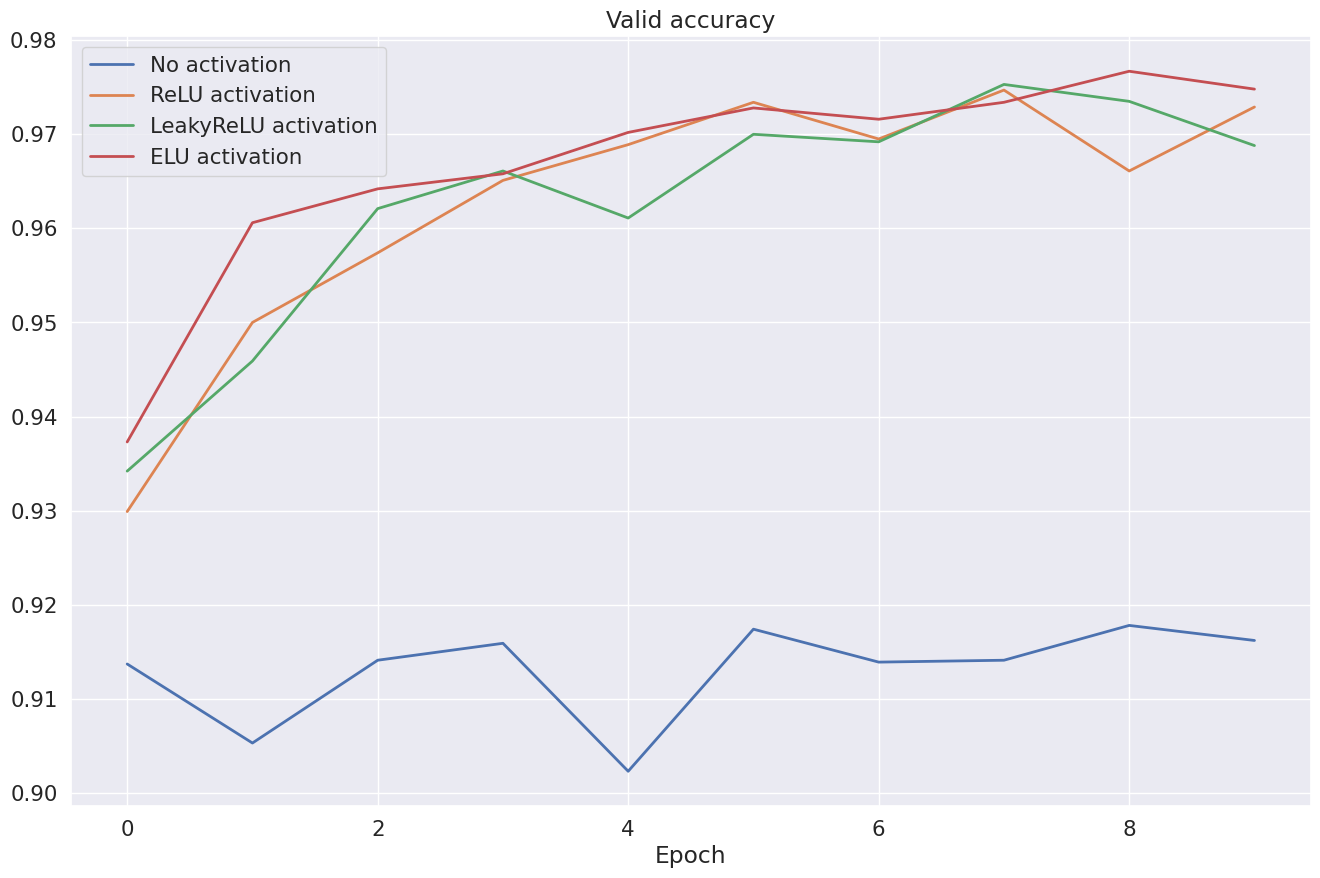

In [ ]:
sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), plain_accuracy, label="No activation", linewidth=2)
plt.plot(range(max_epochs), relu_accuracy, label="ReLU activation", linewidth=2)
plt.plot(range(max_epochs), leaky_relu_accuracy, label="LeakyReLU activation", linewidth=2)
plt.plot(range(max_epochs), elu_accuracy, label="ELU activation", linewidth=2)
plt.legend()
plt.xlabel("Epoch")
plt.show()

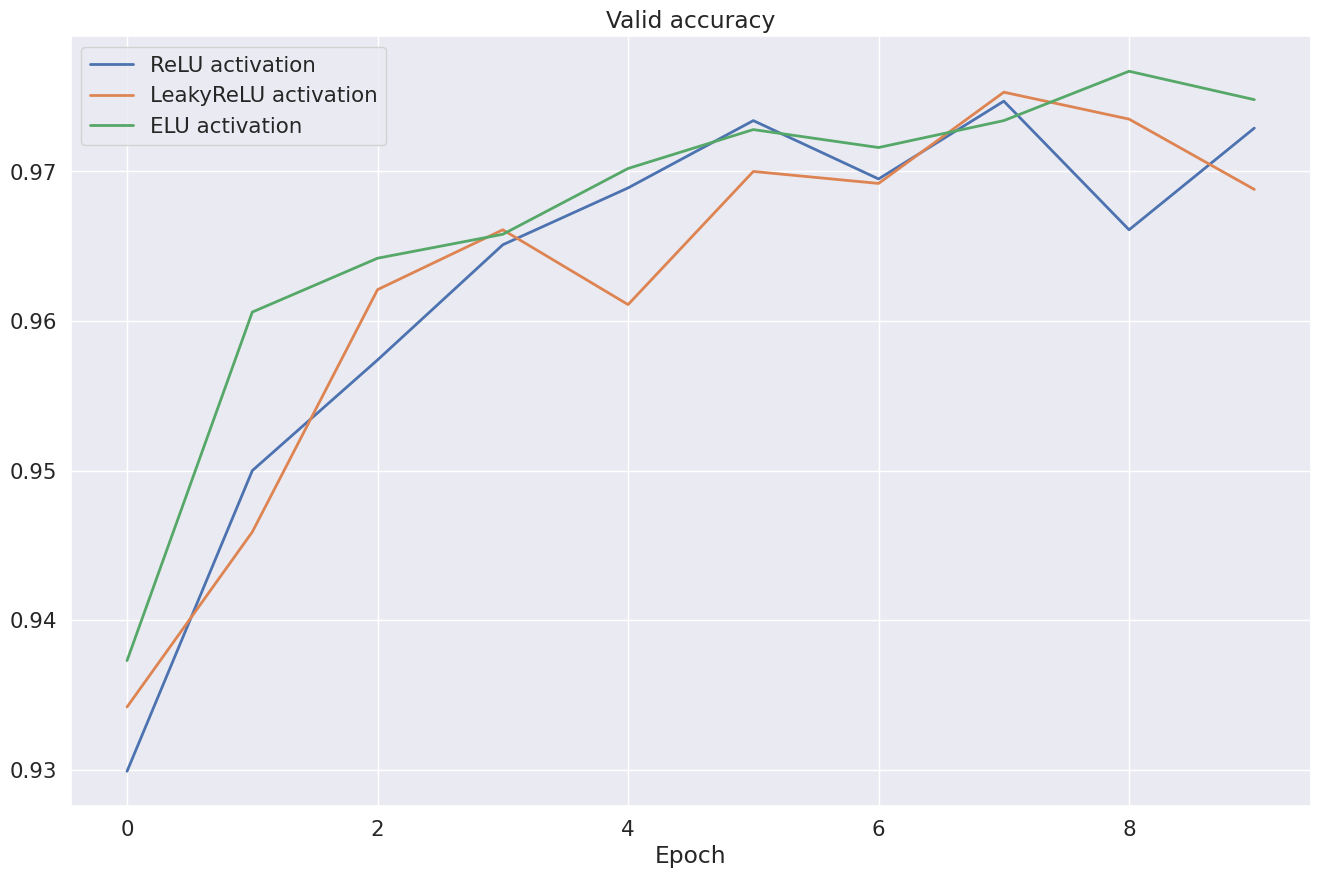

In [ ]:
plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), relu_accuracy, label="ReLU activation", linewidth=2)
plt.plot(range(max_epochs), leaky_relu_accuracy, label="LeakyReLU activation", linewidth=2)
plt.plot(range(max_epochs), elu_accuracy, label="ELU activation", linewidth=2)
plt.legend()
plt.xlabel("Epoch")
plt.show()

**Вопрос 4.** Какая из активаций показала наивысший `accuracy` к концу обучения?

**Ответ:** Epoch: 10, Loader: train, Accuracy: 0.9838


## Часть 2.2 Сверточные нейронные сети

### Ядра
Сначала немного поработам с самим понятием ядра свёртки.

In [ ]:
!wget https://img.the-village.kz/the-village.com.kz/post-cover/5x5-I6oiwjmq79dMCZMEbA-default.jpg -O sample_photo.jpg

--2025-04-07 18:32:34--  https://img.the-village.kz/the-village.com.kz/post-cover/5x5-I6oiwjmq79dMCZMEbA-default.jpg
Resolving img.the-village.kz (img.the-village.kz)... 5.9.226.237
Connecting to img.the-village.kz (img.the-village.kz)|5.9.226.237|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 49337 (48K) [image/jpeg]
Saving to: ‘sample_photo.jpg’

sample_photo.jpg    100%[===================>]  48.18K   156KB/s    in 0.3s    

2025-04-07 18:32:35 (156 KB/s) - ‘sample_photo.jpg’ saved [49337/49337]



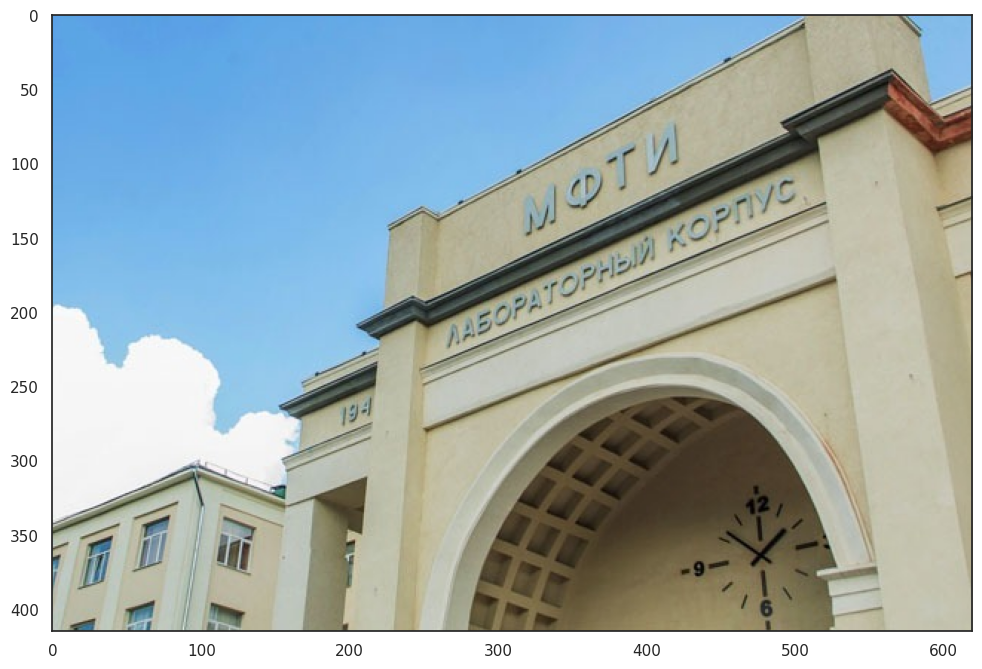

In [ ]:
import cv2
sns.set(style="white")
img = cv2.imread("sample_photo.jpg")
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(RGB_img)
plt.show()

Попробуйте посмотреть как различные свертки влияют на фото. Например, попробуйте
A)
```
[0, 0, 0],
[0, 1, 0],
[0, 0, 0]
```
Б)
```
[0, 1, 0],
[0, -2, 0],
[0, 1, 0]
```
В)
```
[0, 0, 0],
[1, -2, 1],
[0, 0, 0]
```
Г)
```
[0, 1, 0],
[1, -4, 1],
[0, 1, 0]
```
Д)
```
[0, -1, 0],
[-1, 5, -1],
[0, -1, 0]
```
Е)
```
[0.0625, 0.125, 0.0625],
[0.125, 0.25, 0.125],
[0.0625, 0.125, 0.0625]
```

Не стесняйтесь пробовать свои варианты!

In [ ]:
conv_1 = np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]]) # A
conv_2 = np.array([[0, 1, 0], [0, -2, 0], [0, 1, 0]]) # Б
conv_3 = np.array([[0, 0, 0], [1, -2, 1], [0, 0, 0]]) # В
conv_4 = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]]) # Г
conv_5 = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]) # Д
conv_6 = np.array([[0.0625, 0.125, 0.0625], [0.125, 0.25, 0.125], [0.0625, 0.125, 0.0625]]) # E

In [ ]:
img_t = torch.from_numpy(RGB_img).type(torch.float32).unsqueeze(0)
kernel = torch.tensor(conv_6).reshape(1, 1, 3, 3).type(torch.float32)

kernel = kernel.repeat(3, 3, 1, 1)
img_t = img_t.permute(0, 3, 1, 2)  # [BS, H, W, C] -> [BS, C, H, W]
img_t = nn.ReflectionPad2d(1)(img_t)  # Pad Image for same output size

result = F.conv2d(img_t, kernel)[0]  #

In [ ]:
img_t = torch.from_numpy(RGB_img).type(torch.float32).unsqueeze(0)
kernel = torch.tensor([
    [0, 0, 0],
    [1, -2, 1],
    [0, 0, 0]
]).reshape(1, 1, 3, 3).type(torch.float32)

kernel = kernel.repeat(3, 3, 1, 1)
img_t = img_t.permute(0, 3, 1, 2)  # [BS, H, W, C] -> [BS, C, H, W]
img_t = nn.ReflectionPad2d(1)(img_t)  # Pad Image for same output size

result = F.conv2d(img_t, kernel)[0]  #

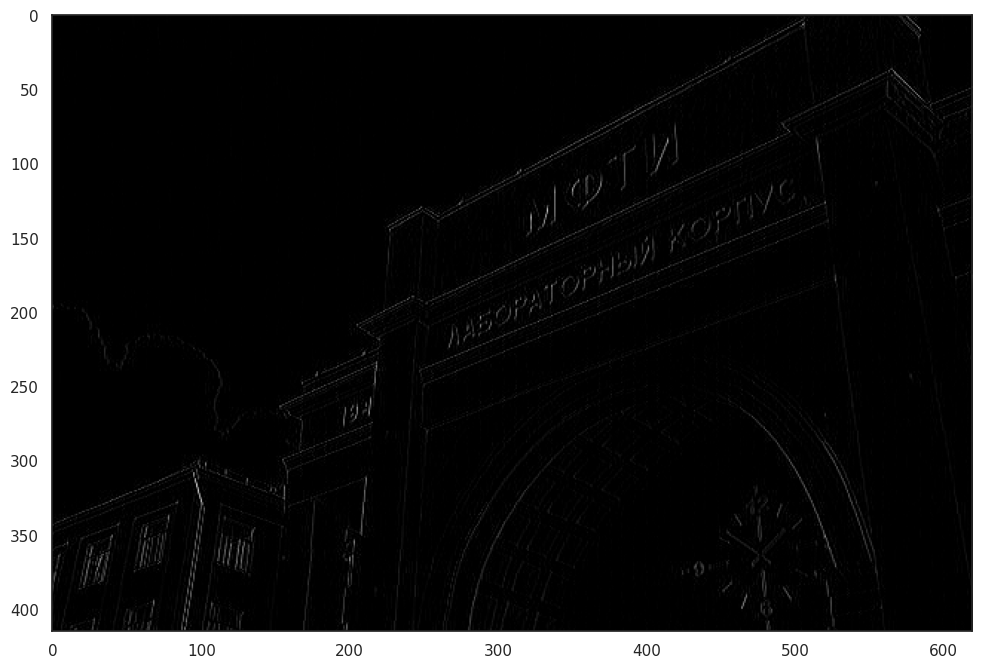

In [ ]:
plt.figure(figsize=(12, 8))
result_np = result.permute(1, 2, 0).numpy() / 256 / 3

plt.imshow(result_np)
plt.show()

**Вопрос 5.** Как можно описать действия ядер, приведенных выше? Сопоставьте для каждой буквы число.

1) Размытие

2) Увеличение резкости

3) Тождественное преобразование

4) Выделение вертикальных границ

5) Выделение горизонтальных границ

6) Выделение границ

**Ответ:**

### Задание. Реализуйте LeNet

Если мы сделаем параметры сверток обучаемыми, то можем добиться хороших результатов для задач компьютерного зрения. Реализуйте архитектуру LeNet, предложенную еще в 1998 году!
На этот раз используйте модульную структуру (без помощи класса Sequential).

Наша нейронная сеть будет состоять из
* Свёртки 3x3 (1 карта на входе, 6 на выходе) с активацией ReLU;
* MaxPooling-а 2x2;
* Свёртки 3x3 (6 карт на входе, 16 на выходе) с активацией ReLU;
* MaxPooling-а 2x2;
* Уплощения (nn.Flatten);
* Полносвязного слоя со 120 нейронами и активацией ReLU;
* Полносвязного слоя с 84 нейронами и активацией ReLU;
* Выходного слоя из 10 нейронов.




In [ ]:

class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 3)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(nn.ReLU()(self.conv1(x)))
        x = self.pool2(nn.ReLU()(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = nn.ReLU()(self.fc1(x))
        x = nn.ReLU()(self.fc2(x))
        x = self.fc3(x)
        return x


In [ ]:
model = LeNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

loaders = {"train": train_dataloader, "valid": valid_dataloader}

### Задание. Обучите CNN
Используйте код обучения, который вы написали для полносвязной нейронной сети.

In [ ]:

from torchvision import datasets, transforms
import torch.optim as optim

# Настроим трансформации для изображений MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Загрузим датасеты для обучения и тестирования
train_dataset = datasets.MNIST(root='./', train=True, download=True, transform=transform)
valid_dataset = datasets.MNIST(root='./', train=False, download=True, transform=transform)

# Создадим DataLoader для батчей
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

# Инициализация модели, функции потерь и оптимизатора
model = LeNet()  # Используем модель LeNet
criterion = nn.CrossEntropyLoss()  # Функция потерь для классификации
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Оптимизатор Adam

# Словарь для отслеживания точности
accuracy = {"train": [], "valid": []}

# Цикл обучения
max_epochs = 10
for epoch in range(max_epochs):
    model.train()  # Устанавливаем модель в режим обучения
    epoch_correct = 0
    epoch_all = 0
    for x_batch, y_batch in train_dataloader:
        optimizer.zero_grad()  # Обнуляем градиенты

        # Прямой проход (forward pass)
        outp = model(x_batch)

        # Вычисление потерь
        loss = criterion(outp, y_batch)

        # Обратный проход (backward pass) и шаг оптимизатора
        loss.backward()
        optimizer.step()

        # Прогнозирование и вычисление точности
        preds = outp.argmax(-1)  # Прогнозы (класс с максимальной вероятностью)
        correct = (preds == y_batch).sum().item()
        all = y_batch.size(0)

        epoch_correct += correct
        epoch_all += all

    # Вычисляем точность для обучающего набора
    train_accuracy = epoch_correct / epoch_all
    accuracy["train"].append(train_accuracy)

    # Оценка на валидационном наборе
    model.eval()  # Устанавливаем модель в режим оценки
    epoch_correct = 0
    epoch_all = 0
    with torch.no_grad():  # Отключаем вычисление градиентов для валидации
        for x_batch, y_batch in valid_dataloader:
            outp = model(x_batch)

            preds = outp.argmax(-1)
            correct = (preds == y_batch).sum().item()
            all = y_batch.size(0)

            epoch_correct += correct
            epoch_all += all

    valid_accuracy = epoch_correct / epoch_all
    accuracy["valid"].append(valid_accuracy)

    # Печатаем точность на каждой эпохе
    print(f"Epoch {epoch+1}/{max_epochs}, "
          f"Train Accuracy: {train_accuracy:.4f}, "
          f"Valid Accuracy: {valid_accuracy:.4f}")


Epoch 1/10, Train Accuracy: 0.9194, Valid Accuracy: 0.9733
Epoch 2/10, Train Accuracy: 0.9773, Valid Accuracy: 0.9841
Epoch 3/10, Train Accuracy: 0.9841, Valid Accuracy: 0.9810
Epoch 4/10, Train Accuracy: 0.9870, Valid Accuracy: 0.9875
Epoch 5/10, Train Accuracy: 0.9900, Valid Accuracy: 0.9859
Epoch 6/10, Train Accuracy: 0.9912, Valid Accuracy: 0.9866
Epoch 7/10, Train Accuracy: 0.9930, Valid Accuracy: 0.9878
Epoch 8/10, Train Accuracy: 0.9936, Valid Accuracy: 0.9897
Epoch 9/10, Train Accuracy: 0.9944, Valid Accuracy: 0.9901
Epoch 10/10, Train Accuracy: 0.9958, Valid Accuracy: 0.9870


In [ ]:
lenet_accuracy = accuracy["valid"]

Сравним с предыдущем пунктом

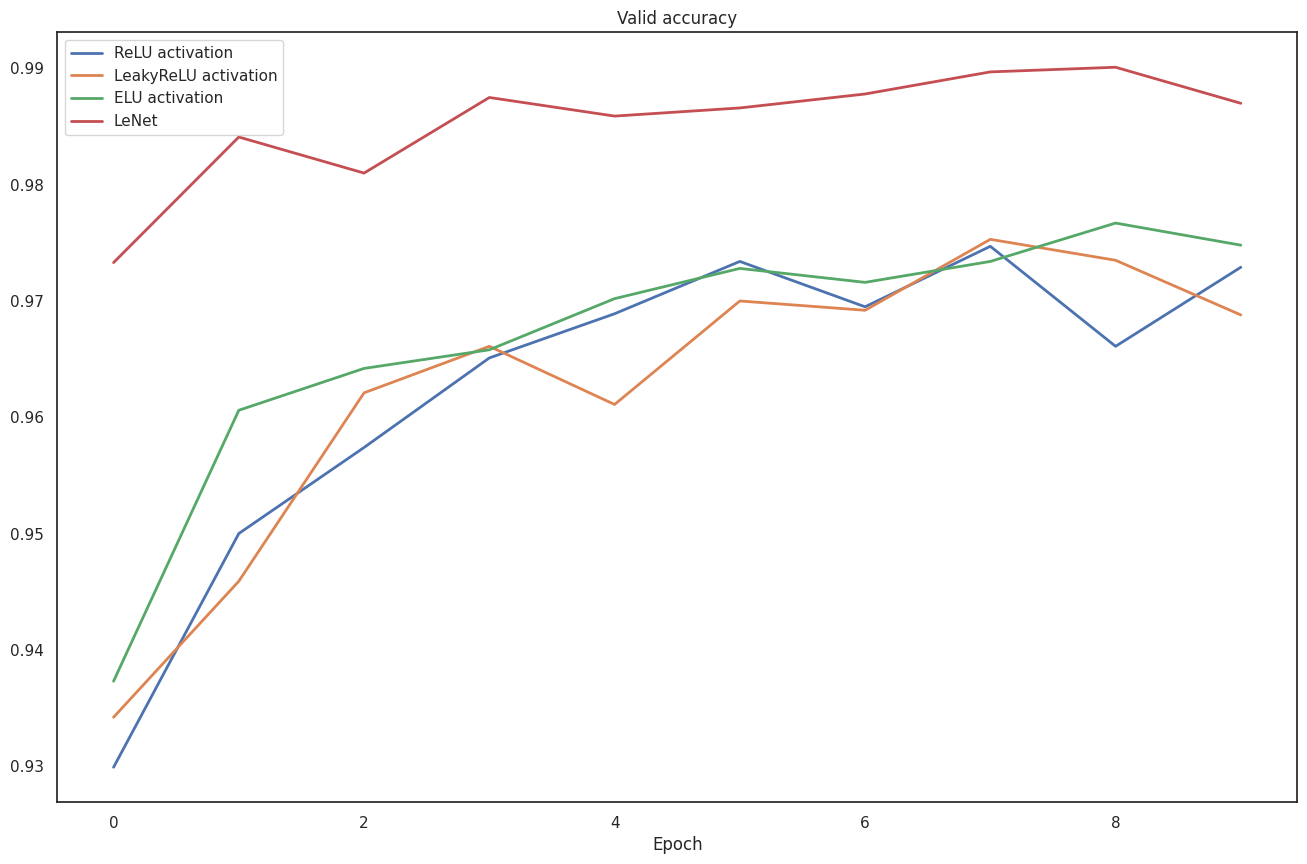

In [ ]:
plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), relu_accuracy, label="ReLU activation", linewidth=2)
plt.plot(range(max_epochs), leaky_relu_accuracy, label="LeakyReLU activation", linewidth=2)
plt.plot(range(max_epochs), elu_accuracy, label="ELU activation", linewidth=2)
plt.plot(range(max_epochs), lenet_accuracy, label="LeNet", linewidth=2)
plt.legend()
plt.xlabel("Epoch")
plt.show()